# EDA Assignment
**Name:** Mahesh Babu Thathineni

**Assignment Title:** Exploratory Data Analysis — Retail Sales Dataset

## Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200
data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}
missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan
data["order_value"][5] = 95000
data["order_value"][88] = 87000
df = pd.DataFrame(data)
print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


---
## Task 1 — Inspect & Handle Missing Values

In [2]:
# 1. Print the shape of the DataFrame
print("Shape of DataFrame (rows, columns):", df.shape)

Shape of DataFrame (rows, columns): (200, 6)


In [3]:
# 2. Display the data types of all columns
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


In [4]:
# 3. Count the number of missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64


In [5]:
# 4. Calculate the percentage of missing values per column, rounded to 2 decimal places
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:")
print(missing_percentage.round(2))

Percentage of missing values per column:
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


---
## Task 2 — Summarize & Visualize

In [6]:
# 1. Summary statistics for all numerical columns
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


**Two observations from the summary:**

1. The `order_value` column has a maximum value of 95,000 which is dramatically higher than the 75th percentile (~3,773), indicating the presence of extreme outliers (rows 5 and 88 were set to 95,000 and 87,000 respectively).

2. The `delivery_days` column shows a mean of approximately 7.5 days with a range from 1 to 14, suggesting a fairly uniform distribution across the delivery window with no extreme outliers.

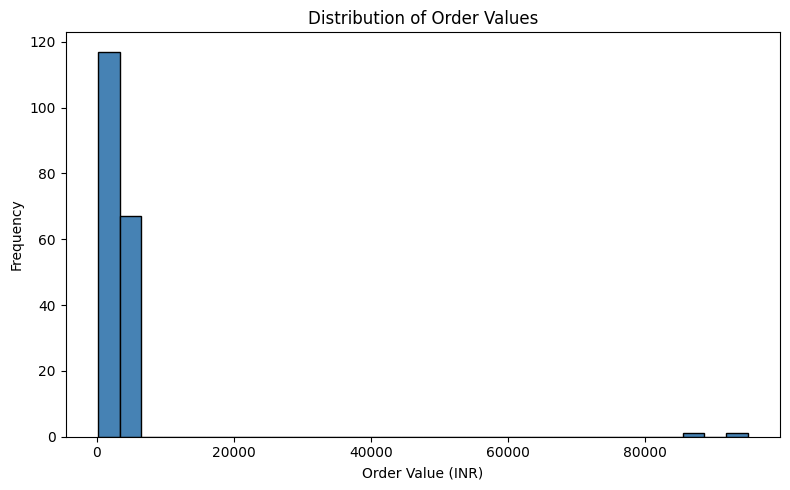

In [7]:
# 2. Histogram for the order_value column
plt.figure(figsize=(8, 5))
plt.hist(df['order_value'].dropna(), bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Order Values')
plt.xlabel('Order Value (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

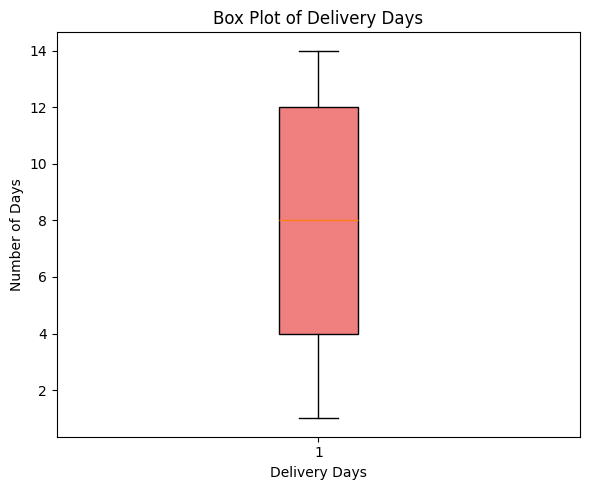

In [8]:
# 3. Box plot for the delivery_days column
plt.figure(figsize=(6, 5))
plt.boxplot(df['delivery_days'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='black'))
plt.title('Box Plot of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Days')
plt.tight_layout()
plt.show()

---
## Task 3 — Correlation Analysis

In [9]:
# 1. Compute the correlation matrix for all numerical columns
corr_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


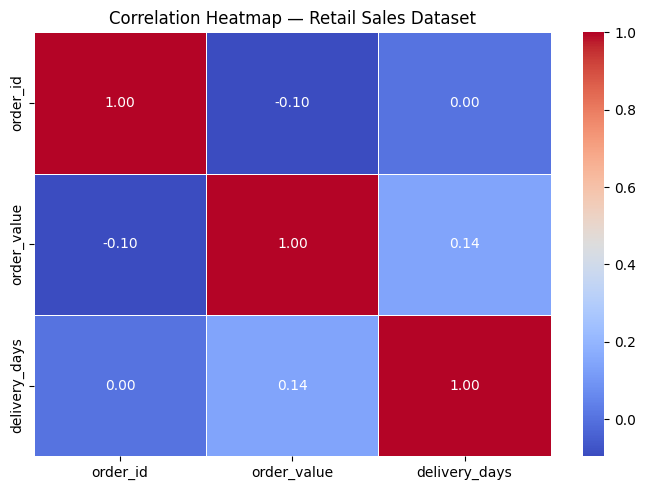

In [10]:
# 2. Heatmap of the correlation matrix with annotation values
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white'
)
plt.title('Correlation Heatmap — Retail Sales Dataset')
plt.tight_layout()
plt.show()

**One observation from the heatmap:**

The `order_value` and `delivery_days` columns show a near-zero correlation, indicating that the value of an order has no meaningful relationship with how long it takes to deliver — higher-value orders are not delivered faster or slower than lower-value ones.